# Rossmann Store Sales: exploratory data analysis

Covers the three questions that drive every downstream decision in this project: how much of the data is missing, what the store hierarchy looks like, and what seasonal structure the feature engineering and models need to capture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 4)

train = pd.read_csv("../data/raw/train.csv", parse_dates=["Date"], low_memory=False)
store = pd.read_csv("../data/raw/store.csv")
test = pd.read_csv("../data/raw/test.csv", parse_dates=["Date"])

print(f"train: {train.shape}, store: {store.shape}, test: {test.shape}")
print(f"date range: {train.Date.min().date()} to {train.Date.max().date()}")
print(f"stores in train: {train.Store.nunique()}, stores in store.csv: {store.Store.nunique()}")

train: (1017209, 9), store: (1115, 10), test: (41088, 8)
date range: 2013-01-01 to 2015-07-31
stores in train: 1115, stores in store.csv: 1115


## Missingness

`train.csv` has no missing values at all. `store.csv` does: competition and Promo2 fields are missing together in blocks, which is informative rather than random.

In [2]:
print("train.csv missing values:")
print(train.isna().sum())
print()
print("store.csv missing values:")
print(store.isna().sum())

train.csv missing values:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

store.csv missing values:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


`CompetitionDistance` is missing for only 3 stores (no nearby competitor recorded, or genuinely unknown). `CompetitionOpenSinceMonth`/`Year` are missing together for 354 stores, and `Promo2SinceWeek`/`Year`/`PromoInterval` are missing together for 544 stores. Both blocks share the same cause: **the store never entered that state** (no known competition-open date; never enrolled in Promo2). These aren't values to impute, they're a category to encode explicitly (a `has_competition_since` / `has_promo2` flag), or a naive median-fill will invent a false signal for roughly a third of the stores.

## Hierarchy: store type and assortment

1,115 stores, each with a fixed `StoreType` (a/b/c/d) and `Assortment` level (a/b/c). Both are static per store, so they're store-level features, not row-level ones.

In [3]:
print("StoreType counts:")
print(store.StoreType.value_counts())
print()
print("Assortment counts:")
print(store.Assortment.value_counts())
print()
print("StoreType x Assortment cross-tab:")
print(pd.crosstab(store.StoreType, store.Assortment))

StoreType counts:
a    602
d    348
c    148
b     17
Name: StoreType, dtype: int64

Assortment counts:
a    593
c    513
b      9
Name: Assortment, dtype: int64

StoreType x Assortment cross-tab:
Assortment    a  b    c
StoreType              
a           381  0  221
b             7  9    1
c            77  0   71
d           128  0  220


Type `b` is a distinct, tiny minority: 17 stores, and it's the only type that pairs with assortment `b` at all. Any per-store-type modeling choice (or a backtest split) needs to keep type `b` represented in both halves rather than losing it to a random split.

## Open/closed days

`Open` looks like it should be redundant with `Sales == 0`, worth checking directly before trusting either column downstream.

In [4]:
closed = train[train.Open == 0]
open_days = train[train.Open == 1]

print(f"open-day rows: {len(open_days)}, closed-day rows: {len(closed)}")
print(f"closed days with nonzero sales: {(closed.Sales != 0).sum()}")
print(f"open days with zero sales: {(open_days.Sales == 0).sum()}")

open-day rows: 844392, closed-day rows: 172817
closed days with nonzero sales: 0
open days with zero sales: 54


Clean: every closed day has zero sales, and the 54 open days with zero sales are a small, explicit edge case (store open but no transactions) rather than a data quality problem, worth excluding from a sales-conditioned average but keeping for a "did the store open" model.

## Seasonality: day of week

Mean sales by day of week, restricted to days the store was actually open.

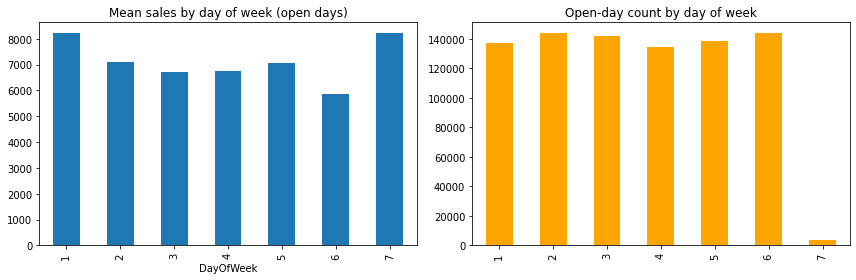

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64


In [5]:
dow_sales = open_days.groupby("DayOfWeek").Sales.mean()
dow_counts = open_days.DayOfWeek.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dow_sales.plot(kind="bar", ax=axes[0], title="Mean sales by day of week (open days)")
dow_counts.plot(kind="bar", ax=axes[1], title="Open-day count by day of week", color="orange")
plt.tight_layout()
plt.show()

print(dow_sales)

Sunday (day 7) looks like the best sales day by a wide margin, but that's selection bias, not seasonality: only 3,593 of 144,730 Sunday rows are `Open == 1` (about 2.5%), against roughly 94-99% on every other day. The stores that choose to open Sunday are a self-selected, presumably high-traffic minority, so their mean isn't comparable to the other six days. Any day-of-week feature needs to either exclude Sunday from a like-for-like comparison or encode it separately from the Mon-Sat pattern, and a naive "Sunday drives sales" read would be wrong.

## Seasonality: trend over time

Total daily sales across all stores, aggregated to monthly to see the trend and yearly seasonality without daily noise.

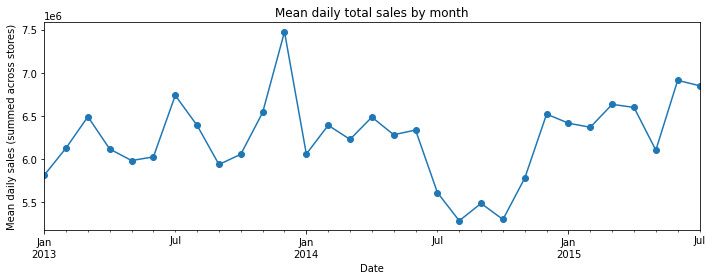

In [6]:
daily_total = train.groupby("Date").Sales.sum()
monthly_total = daily_total.resample("MS").mean()

fig, ax = plt.subplots()
monthly_total.plot(ax=ax, marker="o", title="Mean daily total sales by month")
ax.set_ylabel("Mean daily sales (summed across stores)")
plt.tight_layout()
plt.show()

There's a clear December spike each year (holiday shopping) and a softer trough in the summer months, consistent across both full years in the data (2013, 2014). That's the seasonal pattern SARIMA/Prophet need a full yearly cycle of history to fit, and it's also the reason an expanding-window backtest matters more here than a single holdout split: a holdout that happens to land on a December boundary would give a misleading error estimate in either direction.

## Promo and holiday effects

In [7]:
promo_sales = open_days.groupby("Promo").Sales.mean()
holiday_sales = open_days.groupby("StateHoliday").Sales.mean()
school_sales = open_days.groupby("SchoolHoliday").Sales.mean()

print("Mean sales, promo vs no promo:")
print(promo_sales)
print()
print("Mean sales by StateHoliday code (0 = none, a/b/c = holiday types):")
print(holiday_sales)
print()
print("Mean sales, school holiday vs not:")
print(school_sales)

Mean sales, promo vs no promo:
Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

Mean sales by StateHoliday code (0 = none, a/b/c = holiday types):
StateHoliday
0    6953.515034
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

Mean sales, school holiday vs not:
SchoolHoliday
0    6896.782411
1    7200.181650
Name: Sales, dtype: float64


Promo days average about 39% higher sales (8,228 vs 5,929) on days the store is open, so `Promo` is one of the strongest features available and needs to be known at forecast time, not inferred. State holidays also show higher average sales, not lower, which likely reflects that only a subset of stores choose to open on a state holiday at all, so this needs the same selection-bias caveat as the Sunday numbers above rather than a face-value read.

## Per-store variation

How much does the sales level vary store to store, independent of any time pattern?

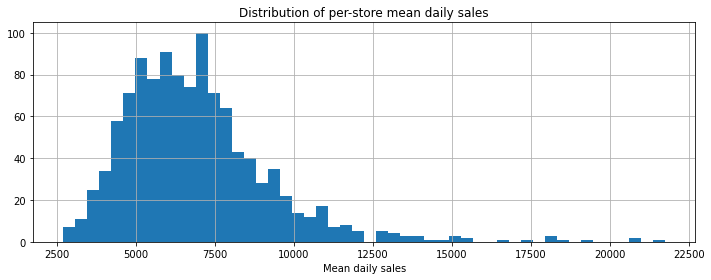

min: 2704, median: 6590, max: 21757
std / median: 0.36


In [8]:
store_avg = open_days.groupby("Store").Sales.mean()

fig, ax = plt.subplots()
store_avg.hist(bins=50, ax=ax)
ax.set_title("Distribution of per-store mean daily sales")
ax.set_xlabel("Mean daily sales")
plt.tight_layout()
plt.show()

print(f"min: {store_avg.min():.0f}, median: {store_avg.median():.0f}, max: {store_avg.max():.0f}")
print(f"std / median: {store_avg.std() / store_avg.median():.2f}")

Store-level mean sales range from about 2,700 to 21,800, a roughly 8x spread, with std/median around 0.36. That's a bigger source of variance than any single calendar effect measured above, which is the core argument for per-store (or per-store-type) features and for WAPE/sMAPE over a metric that isn't scale-normalized, since a single global MAPE would be dominated by the highest-volume stores.

## Takeaways for feature engineering and modeling

- Missingness in `store.csv` is structural (no competition yet, no Promo2 enrollment), so it becomes a flag feature, not something to impute.
- Store type `b` is rare (17 stores) and needs explicit handling in any train/validation split so it isn't dropped by chance.
- `Open` and `Sales` are consistent with each other; the small number of open-zero-sales rows is a real edge case worth keeping separate from the sales-conditioned analysis.
- Day-of-week and state-holiday sales patterns are confounded with which stores choose to open at all; both need to be read alongside open-rate, not as sales-level effects on their own.
- There's a real, consistent December seasonal peak, which argues for at least one full year of history in every backtest fold, and for expanding-window CV over a single holdout split.
- `Promo` is a strong, forecast-time-known feature.
- Per-store sales level varies about 8x across stores, larger than any single seasonal effect, which is the case for store-level features and a scale-normalized error metric.